In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

### Data inspection phase

In [2]:
telco_df = pd.read_csv('Telco-Customer-Churn.csv')
telco_df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [3]:
telco_df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [4]:
telco_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Data preprocessing phase

In [5]:
telco_df['TotalCharges'] = pd.to_numeric(telco_df['TotalCharges'], errors='coerce')

In [6]:
telco_df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [7]:
def clean_telco_data(telco_df):
    """
    Cleans the dataframe by handling missing values,
    removing irrelevant columns, and encoding the target variable (Churn).
    """
    # Removes all missing values
    telco_df = telco_df.dropna()

    # Drops customerID column
    telco_df = telco_df.drop('customerID', axis=1)

    # Encodes target variable
    telco_df['Churn'] = telco_df['Churn'].replace({'No': 0, 'Yes': 1})

    return telco_df

In [8]:
def encode_features(telco_df):
    """
    Converts all categorical variables into dummy variables (0 for false or 1 for true).
    """
    return pd.get_dummies(telco_df, drop_first=True, dtype=int)

In [9]:
def perform_eda(df):
    """
    Performs exploratory data analysis and visualisations.
    """
    churn_correlations = df.corr()[['Churn']].sort_values(by='Churn', ascending=False)

    plt.figure(figsize=(8, 16))
    sns.heatmap(churn_correlations, annot=True, cmap='RdBu_r', vmin=-1, vmax=1)
    plt.title('Feature Correlation with Churn Rate')
    plt.show()

    sns.histplot(x='tenure', data=df)
    plt.title('Distribution of the Tenure Data')
    plt.show()

    sns.scatterplot(x='MonthlyCharges', y='TotalCharges', data=df)
    plt.title('Monthly Charges VS Total Charges')
    plt.xlabel('Monthly Charges')
    plt.ylabel('Total Charges')
    plt.show()

    sns.boxplot(x='Churn', y='tenure', data=df)
    plt.title('Tenure Distribution for Churned and Non-Churned Customers')
    plt.xlabel('Churn (0 = No, 1 = Yes)')
    plt.ylabel('Tenure')
    plt.show()

In [10]:
def scale_and_split(df, target='Churn', test_size=0.25, random_state=42):
    """
    Scales features and splits the dataset into training and test sets.
    """
    X = df.drop(target, axis=1)
    y = df[target]

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

    return train_test_split(
        X_scaled, y,
        test_size=test_size,
        random_state=random_state
    )

In [11]:
def train_evaluate_logistic_regression(X_train, X_test, y_train, y_test):
    """
    Trains and evaluates a Logistic Regression model.
    """
    model = LogisticRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    return {
        "model": model,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }

In [12]:
def train_evaluate_random_forest(X_train, X_test, y_train, y_test):
    """
    Trains and evaluates a Random Forest classifier.
    """
    model = RandomForestClassifier(
        n_estimators=2000,
        oob_score=True,
        max_features='sqrt',
        max_leaf_nodes=50,
        bootstrap=True,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        "model": model,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "oob_error": 1 - model.oob_score_
    }


In [13]:
def format_confusion_matrix(matrix, labels):
    """
    Converts a confusion matrix into a labeled DataFrame.
    """
    return pd.DataFrame(
        matrix,
        index=[f'Actual {label}' for label in labels],
        columns=[f'Predicted {label}' for label in labels]
    )


In [14]:
def compare_models(regression_results, forest_results):
    """
    Creates a comparison table for model precision and recall.
    """
    return pd.DataFrame({
        'Metric': ['Precision', 'Recall'],
        'Logistic Regression': [regression_results['precision'], regression_results['recall']],
        'Random Forest': [forest_results['precision'], forest_results['recall']]
    })

### Data visualisation phase

C:\Users\Nkosingiphile Radebe\AppData\Local\Temp\ipykernel_2660\1341877429.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  telco_df['Churn'] = telco_df['Churn'].replace({'No': 0, 'Yes': 1})


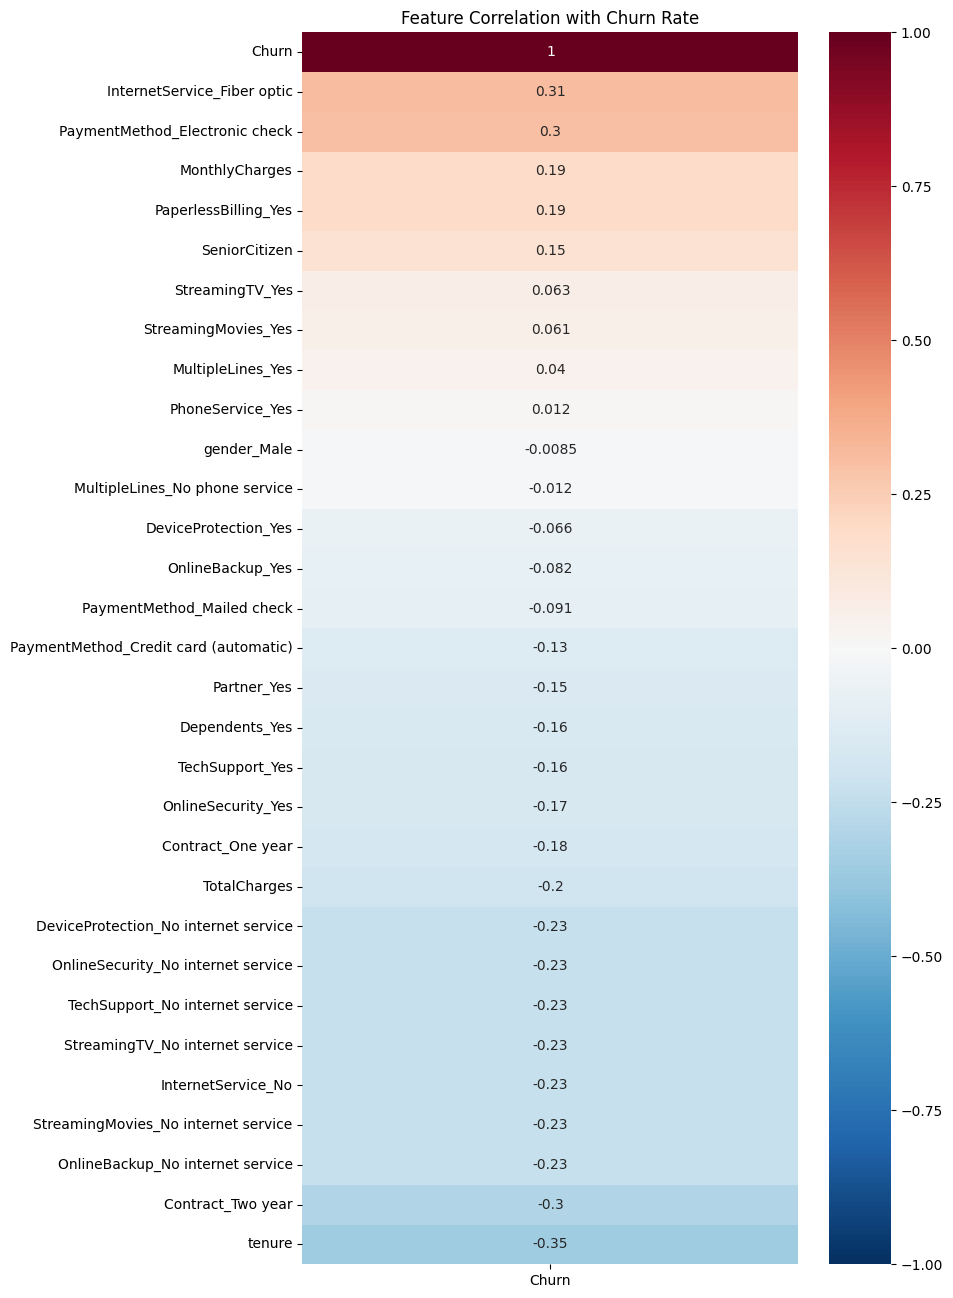

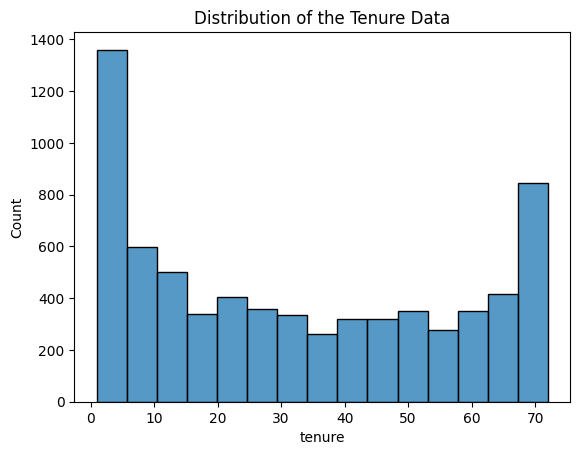

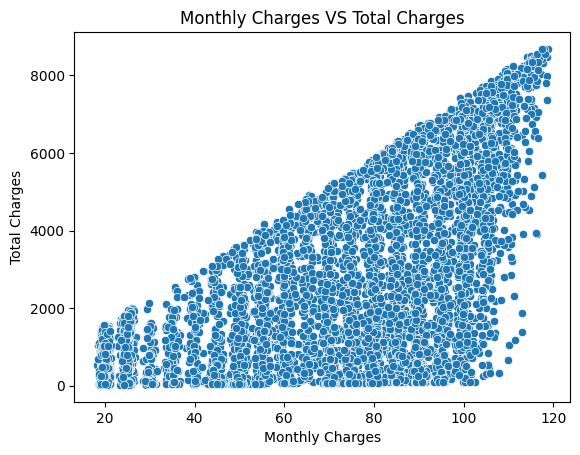

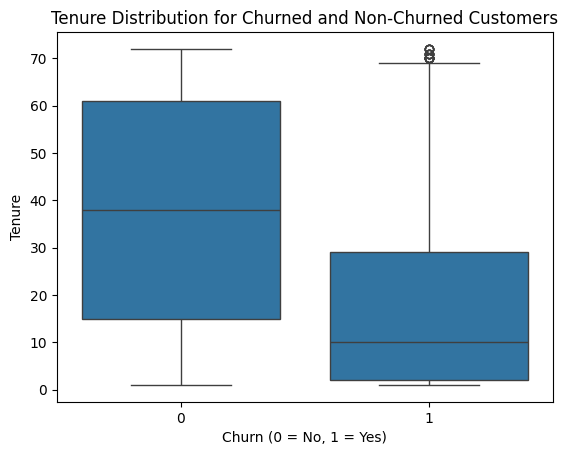

In [16]:
telco_df = clean_telco_data(telco_df)
telecom_cust_dummies = encode_features(telco_df)

perform_eda(telecom_cust_dummies)

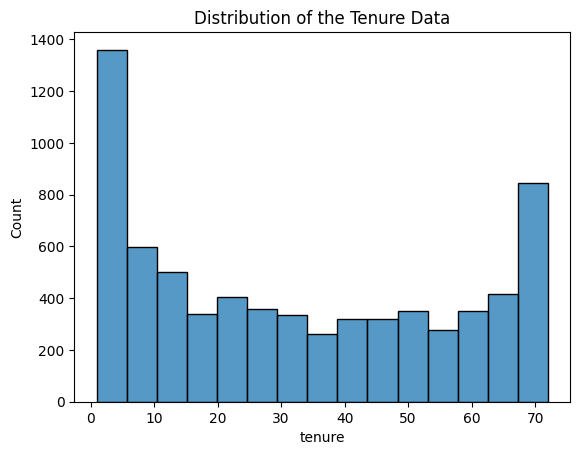

In [48]:
sns.histplot(x='tenure', data=telecom_cust_dummies)
plt.title('Distribution of the Tenure Data')
plt.show()

### Preparations for ML training

In [17]:
X_train, X_test, y_train, y_test = scale_and_split(telecom_cust_dummies)

In [18]:
regression_results = train_evaluate_logistic_regression(X_train, X_test, y_train, y_test)
forest_results = train_evaluate_random_forest(X_train, X_test, y_train, y_test)

print(f"Logistic Regression Accuracy: {regression_results['accuracy']:.4f}")
print(f"Random Forest Accuracy: {forest_results['accuracy']:.4f}")
print(f"Random Forest OOB Error: {forest_results['oob_error']:.4f}")

Logistic Regression Accuracy: 0.7912
Random Forest Accuracy: 0.7935
Random Forest OOB Error: 0.1926


**With a OOB error of 0.19, this means that model is expected to be correct about 80% of the time on unseen data, which means the model generalises unseen data quite well.**

In [20]:
labels = ['Stayed (0)', 'Churned (1)']

print('Logistic Regression Confusion Matrix')
display(format_confusion_matrix(regression_results['confusion_matrix'], labels))

print('Random Forest Confusion Matrix')
display(format_confusion_matrix(forest_results['confusion_matrix'], labels))

print('Logistic Regression vs Random Forest')
display(compare_models(regression_results, forest_results))

Logistic Regression Confusion Matrix


,Predicted Stayed (0),Predicted Churned (1)
Actual Stayed (0),1154,146
Actual Churned (1),221,237


Random Forest Confusion Matrix


,Predicted Stayed (0),Predicted Churned (1)
Actual Stayed (0),1187,113
Actual Churned (1),250,208


Logistic Regression vs Random Forest


,Metric,Logistic Regression,Random Forest
0,Precision,0.618799,0.647975
1,Recall,0.517467,0.454148


**The Confusion Matrix**  
For both models, the "Actual Churned" total is 458 customers (221+237) for Logistic Regression (250+208) for Random Forest.  
Logistic Regression caught 237 churners but missed 221.  
Random Forest caught 208 churners but missed 250.
  
**Precision**  
The Random Forest is more accurate with a 0.6480 precision rate.  
When it flags a customer as "likely to Churn" there is a 64.8% chance they actually will.  
Using the Random Forest model results in fewer "False Positives" (113 vs 146).  
  
**Recall**  
The Logistic Regression is better at locating the people who are leaving with a recall rate of 0.5175.  
It successfully identified 51.7% of all churners, whereas the Random Forest only found 45.4%.  
Logistic Regression is the "safer" model. It missed 29 fewer churners than the Random Forest (221) missed vs (250) missed).
  
Even though the Random Forest model has a higher overall accuracy and better precision, the Logistic Regression model is the better choice for this specific situation because its recall rate is significantly higher.  
Losing a customer is more expensive compared to attempts to retain a loyal customer.